## C0 classifier - new custom split


In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import math
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import os
from sklearn.model_selection import train_test_split


In [2]:
DATA_DIR = "/zhome/d0/a/221493/thesis/data/"

In [3]:
# Take the original train set``
original_train = pd.read_csv(os.path.join(DATA_DIR, "CheXpert-v1.0-small/train.csv"))
print(f"Original train set shape: {original_train.shape}")
original_train

Original train set shape: (223414, 19)


,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223409,CheXpert-v1.0-small/train/patient64537/study2/...,Male,59,Frontal,AP,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,-1.0,0.0,1.0,NaN,NaN,NaN
223410,CheXpert-v1.0-small/train/patient64537/study1/...,Male,59,Frontal,AP,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,0.0,-1.0,NaN,-1.0,NaN,NaN,NaN
223411,CheXpert-v1.0-small/train/patient64538/study1/...,Female,0,Frontal,AP,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
223412,CheXpert-v1.0-small/train/patient64539/study1/...,Female,0,Frontal,AP,NaN,NaN,1.0,1.0,NaN,NaN,NaN,-1.0,1.0,0.0,NaN,NaN,NaN,0.0


In [6]:
# Take the original test set``
original_test = pd.read_csv(os.path.join(DATA_DIR, "CheXpert-v1.0-small/valid.csv"))
print(f"Original test set shape: {original_test.shape}")
original_test

Original test set shape: (234, 19)


,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/valid/patient64541/study1/...,Male,73,Frontal,AP,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CheXpert-v1.0-small/valid/patient64542/study1/...,Male,70,Frontal,PA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,CheXpert-v1.0-small/valid/patient64542/study1/...,Male,70,Lateral,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,CheXpert-v1.0-small/valid/patient64543/study1/...,Male,85,Frontal,AP,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CheXpert-v1.0-small/valid/patient64544/study1/...,Female,42,Frontal,AP,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,CheXpert-v1.0-small/valid/patient64736/study1/...,Female,57,Frontal,AP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
230,CheXpert-v1.0-small/valid/patient64737/study1/...,Male,65,Frontal,AP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
231,CheXpert-v1.0-small/valid/patient64738/study1/...,Male,71,Frontal,AP,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
232,CheXpert-v1.0-small/valid/patient64739/study1/...,Female,45,Frontal,AP,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Removing non-FRONTAL images

In [21]:
# Remove non-FRONTAL images
original_train = original_train[original_train["Frontal/Lateral"] == "Frontal"]
original_test = original_test[original_test["Frontal/Lateral"] == "Frontal"]
print(f"Train set shape after removing non-FRONTAL images: {original_train.shape}")
print(f"Test set shape after removing non-FRONTAL images: {original_test.shape}")

Train set shape after removing non-FRONTAL images: (191027, 19)
Test set shape after removing non-FRONTAL images: (202, 19)


## Replacing missing values with 0 (Assume negative)

In [22]:
OBSERVATIONS = [
    "No Finding", "Enlarged Cardiomediastinum", "Cardiomegaly", "Lung Opacity",
    "Lung Lesion", "Edema", "Consolidation", "Pneumonia", "Atelectasis",
    "Pneumothorax", "Pleural Effusion", "Pleural Other", "Fracture",
    "Support Devices",
]

In [23]:
# Replace missing values with "missing" string
filled_train = original_train.copy()
filled_train[OBSERVATIONS] = filled_train[OBSERVATIONS].fillna(0.0)

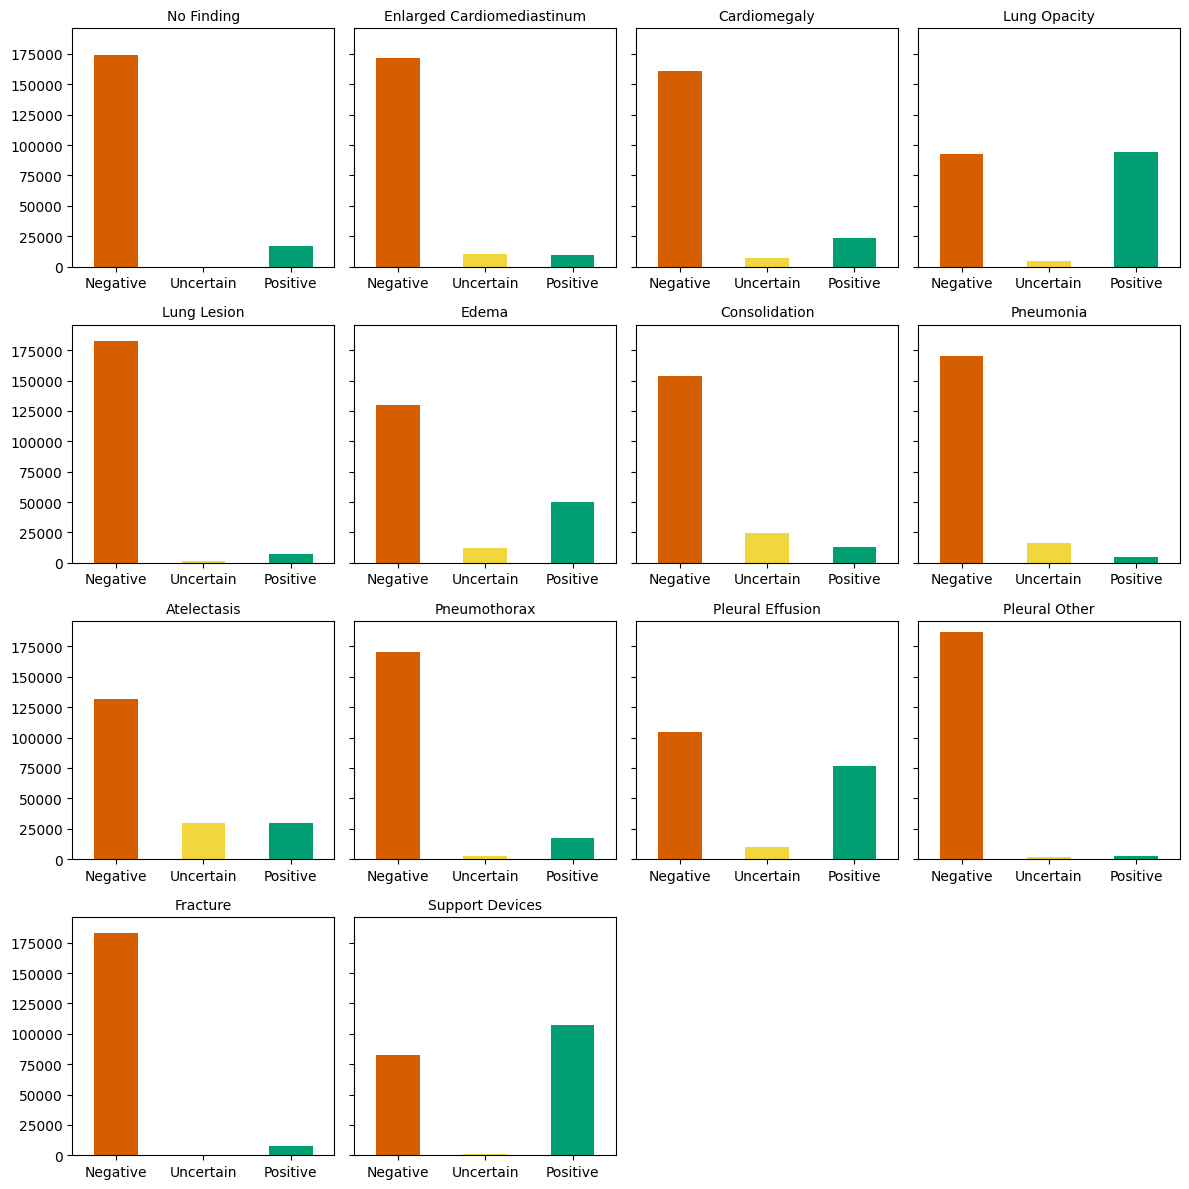

In [24]:
label_counts = (
    filled_train[OBSERVATIONS]
    .apply(lambda s: s.value_counts())
    .T
    .reindex(columns=[0.0, -1.0, 1.0], fill_value=0)
)
label_counts.columns = ["Negative", "Uncertain", "Positive"]

LABEL_COLORS = {
    "Negative":  "#D55E00",   # teal-green  (matches M2)
    "Uncertain": "#F1D63D",   # yellow      (matches B3)
    "Positive":  "#009E73",   # vermillion  (matches B5)
}

fig, axes = plt.subplots(4, 4, figsize=(12, 12), sharey=True)

for ax, obs in zip(axes.flat, OBSERVATIONS):
    row = label_counts.loc[obs]
    row.plot(kind="bar", ax=ax, color=[LABEL_COLORS[c] for c in row.index])
    ax.set_title(obs, fontsize=10)
    ax.tick_params(axis="x", rotation=0)

for ax in axes.flat[len(OBSERVATIONS):]:
    ax.axis("off")

plt.tight_layout()

# Spliting
### 50% for C0 training and 50% for C2 Train/test split


In [25]:
# --- Patient-level three-way split -------------------------------------------
# Path is CheXpert-v1.0-small/train/patientXXXXX/studyY/viewZ.jpg
filled_train["patient_id"] = filled_train["Path"].apply(lambda p: p.split("/")[2])
patients = filled_train["patient_id"].unique()
print(f"{len(patients)} unique patients, {len(filled_train)} images")

64534 unique patients, 191027 images


In [26]:
# --- Outer split: 50% C0, 50% C2 ---------------------------------------------
c0_p, c2_p = train_test_split(patients, test_size=0.5, random_state=42)

# --- Inner split of the C0 half: 90% train, 10% checkpoint selection ---------
train_p, select_p = train_test_split(c0_p, test_size=0.1, random_state=42)

splits = {
    "C0_train":  filled_train[filled_train["patient_id"].isin(train_p)],
    "C0_checkpoint_selection": filled_train[filled_train["patient_id"].isin(select_p)],
    "C2_dataset":   filled_train[filled_train["patient_id"].isin(c2_p)],
}

In [27]:

# --- Verify: no patient overlap, and prevalences match across splits ----------
ids = {k: set(v["patient_id"]) for k, v in splits.items()}
assert not (ids["C0_train"] & ids["C0_checkpoint_selection"]), "train/select patient overlap"
assert not (ids["C0_train"] & ids["C2_dataset"]),   "train/dataset patient overlap"
assert not (ids["C0_checkpoint_selection"] & ids["C2_dataset"]),  "select/dataset patient overlap"

for name, df in splits.items():
    print(f"{name}: {len(df)} images, {df['patient_id'].nunique()} patients")

# Positive rate per observation per split. Columns should agree to <1pp.
prev = pd.DataFrame({
    name: (df[OBSERVATIONS] == 1.0).mean()
    for name, df in splits.items()
})
print("Positive rate per observation per split:")
print(prev.round(4))


C0_train: 85664 images, 29040 patients
C0_checkpoint_selection: 9528 images, 3227 patients
C2_dataset: 95835 images, 32267 patients
Positive rate per observation per split:
                            C0_train  C0_checkpoint_selection  C2_dataset
No Finding                    0.0884                   0.0910      0.0891
Enlarged Cardiomediastinum    0.0480                   0.0532      0.0476
Cardiomegaly                  0.1232                   0.1337      0.1206
Lung Opacity                  0.4929                   0.4955      0.4932
Lung Lesion                   0.0371                   0.0361      0.0367
Edema                         0.2602                   0.2558      0.2604
Consolidation                 0.0674                   0.0703      0.0682
Pneumonia                     0.0238                   0.0232      0.0252
Atelectasis                   0.1542                   0.1499      0.1574
Pneumothorax                  0.0936                   0.0897      0.0921
Pleural Effus

In [28]:
unc = pd.DataFrame({
    name: (df[OBSERVATIONS] == -1.0).mean()
    for name, df in splits.items()
})
print("Uncertain rate per observation per split:")
print(unc.round(4))

Uncertain rate per observation per split:
                            C0_train  C0_checkpoint_selection  C2_dataset
No Finding                    0.0000                   0.0000      0.0000
Enlarged Cardiomediastinum    0.0542                   0.0539      0.0535
Cardiomegaly                  0.0356                   0.0352      0.0346
Lung Opacity                  0.0238                   0.0228      0.0227
Lung Lesion                   0.0058                   0.0045      0.0059
Edema                         0.0612                   0.0631      0.0623
Consolidation                 0.1284                   0.1307      0.1267
Pneumonia                     0.0837                   0.0822      0.0838
Atelectasis                   0.1573                   0.1571      0.1554
Pneumothorax                  0.0143                   0.0134      0.0141
Pleural Effusion              0.0494                   0.0481      0.0510
Pleural Other                 0.0094                   0.0093      0.0

# Saving

In [29]:
for name, df in splits.items():
    df.to_csv(f"{name}.csv", index=False)

In [30]:
# Also saving the test set with missing values replaced by 0.0, and adding patient_id column

filled_test = original_test.copy()
filled_test[OBSERVATIONS] = filled_test[OBSERVATIONS].fillna(0.0)
filled_test["patient_id"] = filled_test["Path"].apply(lambda p: p.split("/")[2])
filled_test.to_csv("Original_Test.csv", index=False)